# Standard Normal Distribution — Demo

This notebook demonstrates **Z-scores**, **standardization**, the **Standard Normal Distribution**, and their applications in Machine Learning.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

## 2. Calculate a Z-Score Manually

The Z-score formula is:

$$
Z = \frac{X-\mu}{\sigma}
$$

Suppose:

- Mean = 4
- Standard deviation = 1
- Data value = 4.25

In [2]:
x = 4.25
mu = 4
sigma = 1

z = (x - mu) / sigma

print(f"Z-score = {z:.2f}")

Z-score = 0.25


The result is:

$$
Z = 0.25
$$

Therefore, `4.25` is **0.25 standard deviations above the mean**.

## 3. Negative Z-Score

Now consider:

- Mean = 4
- Standard deviation = 1
- Data value = 2.5

In [3]:
x = 2.5
mu = 4
sigma = 1

z = (x - mu) / sigma

print(f"Z-score = {z:.2f}")

Z-score = -1.50


The result is:

$$
Z=-1.5
$$

Therefore, `2.5` is **1.5 standard deviations below the mean**.

## 4. Standardizing a Dataset Manually

Consider the values:

```text
1, 2, 3, 4, 5
```

We can calculate the Z-score of every observation.

In [4]:
data = np.array([1, 2, 3, 4, 5])

mu = np.mean(data)
sigma = np.std(data)

z_scores = (data - mu) / sigma

print("Original data:", data)
print("Mean:", mu)
print("Standard deviation:", sigma)
print("Z-scores:", np.round(z_scores, 2))

Original data: [1 2 3 4 5]
Mean: 3.0
Standard deviation: 1.4142135623730951
Z-scores: [-1.41 -0.71  0.    0.71  1.41]


The standardized values should have approximately:

$$
\text{Mean}=0
$$

and:

$$
\text{Standard Deviation}=1
$$

In [5]:
print("Mean of standardized data:", np.mean(z_scores))
print("Standard deviation of standardized data:", np.std(z_scores))

Mean of standardized data: 0.0
Standard deviation of standardized data: 0.9999999999999999


## 5. Standardization Using Scikit-Learn

In practical Machine Learning workflows, `StandardScaler` is commonly used.

In [6]:
data = np.array([[1], [2], [3], [4], [5]])

scaler = StandardScaler()
standardized_data = scaler.fit_transform(data)

print("Original data:")
print(data.flatten())

print("\nStandardized data:")
print(np.round(standardized_data.flatten(), 2))

Original data:
[1 2 3 4 5]

Standardized data:
[-1.41 -0.71  0.    0.71  1.41]


## 6. Verify Mean and Standard Deviation

Let's verify the result of `StandardScaler`.

In [7]:
z = standardized_data.flatten()

print("Mean:", np.mean(z))
print("Standard deviation:", np.std(z))

Mean: 0.0
Standard deviation: 0.9999999999999999


## 7. Standard Normal Distribution

The Standard Normal Distribution has:

$$
\mu=0
$$

$$
\sigma=1
$$

Therefore:

$$
Z \sim N(0,1)
$$

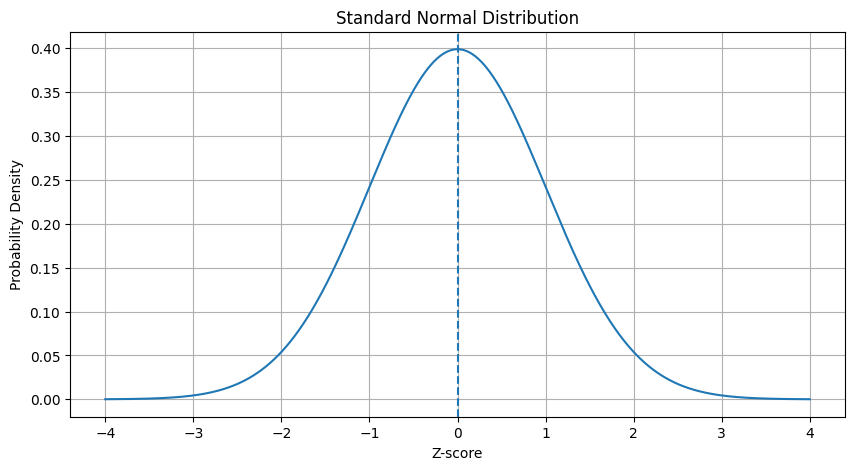

In [8]:
z = np.linspace(-4, 4, 1000)
pdf = norm.pdf(z, 0, 1)

plt.figure(figsize=(10, 5))
plt.plot(z, pdf)
plt.axvline(0, linestyle="--")
plt.xlabel("Z-score")
plt.ylabel("Probability Density")
plt.title("Standard Normal Distribution")
plt.grid(True)
plt.show()

## 8. Interpret Different Z-Scores

Let's see how different Z-scores relate to the mean.

In [9]:
z_values = [-2, -1, 0, 1, 2]

for z in z_values:
    if z > 0:
        interpretation = "above the mean"
    elif z < 0:
        interpretation = "below the mean"
    else:
        interpretation = "at the mean"

    print(f"Z = {z}: {abs(z)} standard deviation(s) {interpretation}")

Z = -2: 2 standard deviation(s) below the mean
Z = -1: 1 standard deviation(s) below the mean
Z = 0: 0 standard deviation(s) at the mean
Z = 1: 1 standard deviation(s) above the mean
Z = 2: 2 standard deviation(s) above the mean


## 9. Probability Using a Z-Score

Suppose:

$$
X \sim N(100,10^2)
$$

Find the probability that `X` is less than or equal to `120`.

First calculate the Z-score:

$$
Z=\frac{120-100}{10}=2
$$

In [10]:
mu = 100
sigma = 10
x = 120

z = (x - mu) / sigma
probability = norm.cdf(z)

print(f"Z-score = {z:.2f}")
print(f"P(X ≤ {x}) = {probability:.4f}")
print(f"Percentage = {probability * 100:.2f}%")

Z-score = 2.00
P(X ≤ 120) = 0.9772
Percentage = 97.72%


## 10. Compare Two Values Using Z-Scores

Suppose two students receive scores in different subjects.

Student A:
- Score = 80
- Mean = 70
- Standard deviation = 5

Student B:
- Score = 90
- Mean = 80
- Standard deviation = 8

The raw scores cannot be directly compared fairly because the two tests have different distributions.

In [11]:
score_a = 80
mean_a = 70
std_a = 5

score_b = 90
mean_b = 80
std_b = 8

z_a = (score_a - mean_a) / std_a
z_b = (score_b - mean_b) / std_b

print(f"Student A Z-score: {z_a:.2f}")
print(f"Student B Z-score: {z_b:.2f}")

Student A Z-score: 2.00
Student B Z-score: 1.25


The Z-scores provide a common scale for comparison.

The student with the larger Z-score performed farther above their respective mean.

## 11. Visualizing Standardized Data

Standardization changes the numerical scale of the feature. It does **not automatically change the underlying distribution shape**.

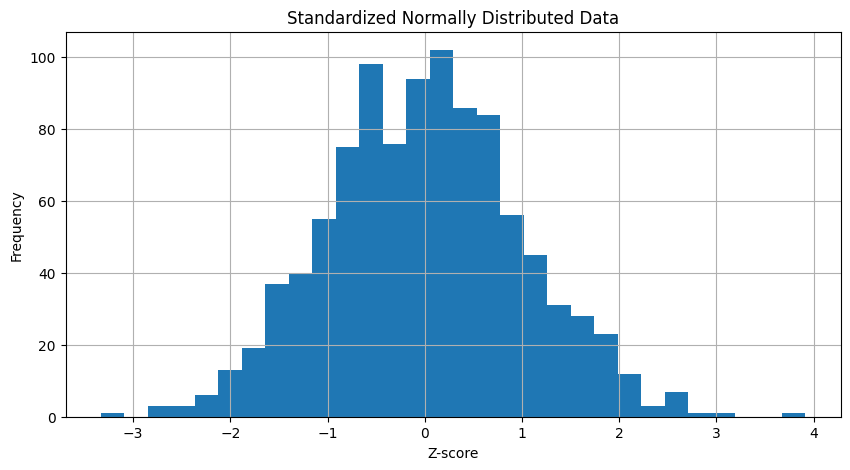

In [12]:
np.random.seed(42)

data = np.random.normal(loc=100, scale=15, size=1000)

z_scores = (data - np.mean(data)) / np.std(data)

plt.figure(figsize=(10, 5))
plt.hist(z_scores, bins=30)
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.title("Standardized Normally Distributed Data")
plt.grid(True)
plt.show()

## 12. Check the Standardized Data

The standardized dataset should have a mean close to 0 and a standard deviation close to 1.

In [13]:
print(f"Mean: {np.mean(z_scores):.4f}")
print(f"Standard Deviation: {np.std(z_scores):.4f}")

Mean: 0.0000
Standard Deviation: 1.0000


## Key Takeaways

- Standard Normal Distribution has mean `0` and standard deviation `1`.
- Z-score measures how many standard deviations an observation is from the mean.
- Standardization transforms a feature to a common scale.
- Standardization does not automatically make data Normally distributed.
- Positive Z-scores indicate values above the mean.
- Negative Z-scores indicate values below the mean.
- Z = 0 means the observation is exactly at the mean.
- Standardization is especially useful for scale-sensitive Machine Learning algorithms.